# Zadanie 2: optymalizacja z ograniczeniami

Termin realizacji: 30 marca 2026

Wybierz funkcję testową wykorzystaną w zadaniu 1.

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Dodaj ograniczenie postaci $x_1^2 + x_2 + b = 0$ ze stałą $b$ dopasowaną w taki sposób, aby żadne minimum lokalne (przynajmniej w zakresie w którym losowany jest punkt początkowy) nie spełniało ograniczenia.
2. Zaimplementuj metodę funkcji kary do rozwiązania tego problemu. Zwróć uwagę, aby metoda wykonywała częściową optymalizację dla każdej wielkości parametru kary $\mu_k$ (wykonanie od 1 do 5 kroków dla ustalonej wartości parametru kary -- do samodzielnego wyboru).
3. Wylosuj 10 punktów z dziedziny przeszukiwania z tabelki. Dla każdego z nich przeprowadź 100 kroków optymalizacji metodą największego spadku ze stałym krokiem. Narysuj wykres zależności wartości funkcji optymalizowanej od kroku optymalizacji.
4. Wykorzystaj ponownie metodę optymalizacji z poprzedniego projektu. Jako funkcję celu i jej gradient przekaż funkcje uwzględniające karę (ogólny schemat):
```
function penalty_gradient_descent(f, f_grad, x0; ...)
    x_k = copy(x0)
    for i in 1:max_iter
        # dodać: wyliczanie współczynnika kary
        function penalized_f(x)
            # do uzupełnienia
        end
        function penalized_f_grad(x)
            # do uzupełnienia
        end
        x_k = gradient_descent(penalized_f, penalized_f_grad, x_k; max_iter=3)
    end
end
```
5. Przeprowadź procedurę dla kilkunastu kroków. Spróbuj zilustrować brak zbieżności, szybką zbieżność i powolną zbieżność.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Zamień metodę największego spadku na metodę gradientów sprzężonych. Metoda ta powinna wykorzystywać przeszukiwanie w kierunku uwzględniające regułę Armijo.
3. Wraz ze zwiększaniem się parametru kary powinna maleć norma gradientu przy której kończymy działanie metody gradientów sprzężonych, na przykład może być równa $10^{-2} / \mu_k$. 

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Wykonaj benchmarking metody z użyciem `BenchmarkTools.jl`. Zanotuj czasy działania wywołań optymalizacji oraz liczbę alokacji. Spróbuj zoptymalizować działanie funkcji korzystając wymienionych tu rad: [Julia performance tips](https://docs.julialang.org/en/v1/manual/performance-tips/). W sprawozdaniu napisz jakie zmiany wykonane i jak wpłynęły na czas działania programu.

Uwagi:

1. Dodanie typów w nagłówku metody przyspiesza kod tylko w rzadkich i bardzo szczególnych sytuacjach, i to tylko dla typów reprezentujących typy (`Core.Type`) lub funkcje.
2. Dobrym pomysłem jest wykonywanie operacji na tablicach w miejscu i unikanie alokacji. Warto też zwrócić uwagę na tzw. _type stability_, czyli unikanie sytuacji w których typ zmiennej zależy od wartości innej zmiennej.


In [154]:
# !!! Na ten moment raczej wersja robocza / wygenerowana do częsci 3.0 i 4.0

## Funkcja: Three-hump camel function - z poprzedniego zadania
$f(x,y)=2x^{2}-1.05x^{4}+{\frac {x^{6}}{6}}+xy+y^{2}$

Ma globalne minimum w punkcie $(0, 0)$ z wartością $f(0,0) = 0$.

In [155]:
function f(x::Vector)
    return 2*x[1]^2 - 1.05*x[1]^4 + x[1]^6/6 + x[1]*x[2] + x[2]^2
end

# Gradient funkcji
function grad_f!(g::Vector, x::Vector)
    g[1] = 4*x[1] - 4.2*x[1]^3 + x[1]^5 + x[2]
    g[2] = x[1] + 2*x[2]
end

# Dziedzina: [-5, 5] x [-5, 5]
const DOMAIN = (-5.0, 5.0)

(-5.0, 5.0)

In [156]:
using LinearAlgebra
using Plots
using Random

In [157]:
# Losowanie 10 punktów z dziedziny DOMAIN × DOMAIN
Random.seed!(42)
function rand_uniform(a, b)
    return [rand() * (b - a) + a, rand() * (b - a) + a]
end

starting_points = [rand_uniform(DOMAIN[1], DOMAIN[2]) for _ in 1:10]
println("Wylosowane punkty startowe:")
for (i, p) in enumerate(starting_points)
    println("  $i: x = $(round.(p, digits=2))")
end

Wylosowane punkty startowe:
  1: x = [1.29, -0.5]
  2: x = [-0.23, 2.03]
  3: x = [1.73, -3.34]
  4: x = [1.13, 1.68]
  5: x = [-0.43, -2.01]
  6: x = [1.61, 1.39]
  7: x = [-1.57, -2.32]
  8: x = [0.16, -4.1]
  9: x = [-2.27, -3.08]
  10: x = [-0.76, -0.15]


In [158]:
function my_optimize_const_step(cost_data, grad_data, x0;
        step=1e-5, maxiter=100000, tol=1e-6)

    x = copy(x0)
    g = similar(x)

    fx = cost_data(x)
    if !isfinite(fx)
        error("cost_data(x0) is not finite (got $fx). Choose a valid x0 / fix 
                cost domain.")
    end

    for k in 1:maxiter
        grad_data(g, x)
        if any(!isfinite, g)
            error("Gradient became non-finite at iter=$k")
        end

        # Jeśli sie przesuwany o bardzo mały gradient 
        if norm(g) < tol
            return x
        end

        x .= x .- step .* g
    end
    # println("Exceeded maxiter=$maxiter without convergence")
    return x
end

# zapisywanie historii punktów
function optimize_with_history(cost, grad!, x0; step=0.01, maxiter=100, tol=1e-6, 
            optimization_function=my_optimize_const_step)
    x = copy(x0)
    history = Float64[]
    for k in 1:maxiter
        #push!(history, cost(x))
        x = optimization_function(cost, grad!, x; step=step, maxiter=1, tol=tol)
        push!(history, cost(x))
    end
    #push!(history, cost(x))
    return x, history
end

optimize_with_history (generic function with 1 method)

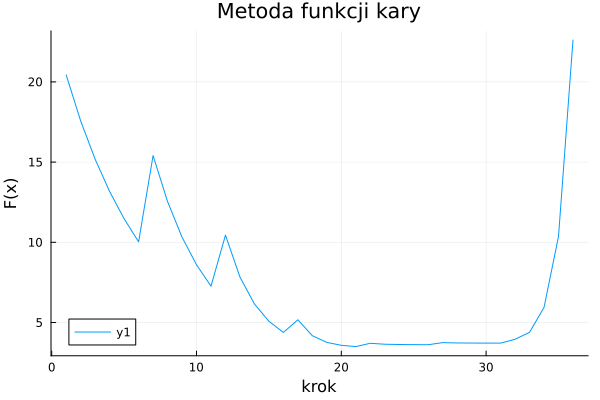

In [159]:
p0 = starting_points[2]

x_opt, history = penalty_gradient_descent(f, grad_f!, p0; μ0=1.0, β=2.0, max_iter=7, iter=5, step=0.02)


plot(history,
     xlabel="krok", ylabel="F(x)", title="Metoda funkcji kary")




100 kroków optymalizacji dla każdego punktu - metoda ze stałym krokiem z zadania 1.

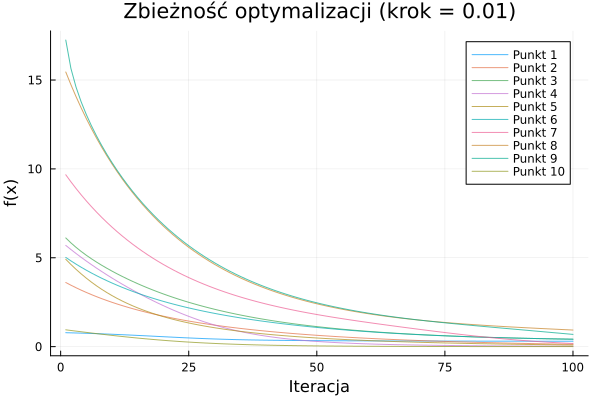

In [160]:
step_size = 0.01
all_histories = []

for x0 in starting_points
    _, hist = optimize_with_history(f, grad_f!, x0, step=step_size, maxiter=100)
    push!(all_histories, hist)
end

# Wykres
p = plot(title="Zbieżność optymalizacji (krok = $step_size)", 
         xlabel="Iteracja", ylabel="f(x)", legend=:topright)
for (i, hist) in enumerate(all_histories)
    plot!(p,  hist, label="Punkt $i", alpha=0.7)
end
display(p)

#### Wprowadzenie nowych elementów

Dodanie ograniczenia postaci $x_1^2 + x_2 + b = 0$. Zgodnie z poleceniem "stałą $b$ dopasowaną w taki sposób, aby żadne minimum lokalne (przynajmniej w zakresie w którym losowany jest punkt początkowy) nie spełniało ograniczenia."  
U nas minimum globale funkcji w punkcie f(0, 0) = 0.  

Stąd dobieramy b = 2.0

Zdefiniowanie funkcji oraz jej gradientu

In [161]:
const b = 2.0

function g(x)
    return x[1]^2 + x[2] + b
end

function grad_g(x)
    return [2*x[1], 1.0]
end

grad_g (generic function with 1 method)

In [162]:
function penalty_gradient_descent(f, grad_f!, x0; μ0 = 1.0, β = 2.0, max_iter = 15, iter=5, step = 0.01)

    x_k = copy(x0)
    μ = μ0

    history = Float64[]
    for i in 1:max_iter

        function penalized_f(x)
            return f(x) + μ * g(x)^2
        end

        function penalized_f_grad!(g_out, x)

            grad_f!(g_out, x)

            gx = g(x)
            gg = grad_g(x)

            g_out .+= 2*μ*gx .* gg
        end
        if i == 1
            append!(history, penalized_f(x_k) )
        end
        x_k, hist = optimize_with_history(
            penalized_f, penalized_f_grad!, x_k;
            step = step, maxiter = iter)

        append!(history, hist)

        μ *= β
    end

    return x_k, history
end

penalty_gradient_descent (generic function with 1 method)

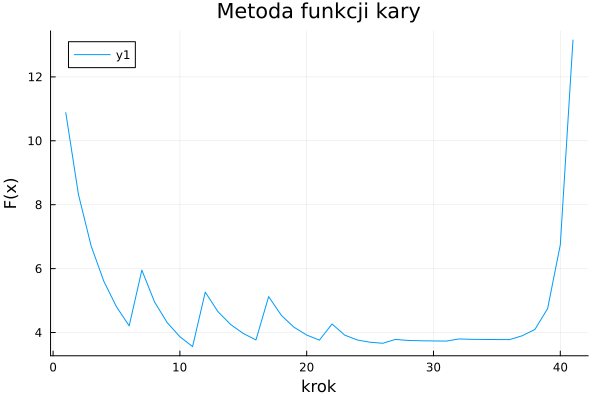

In [163]:
MAXITER = 8

x0 = starting_points[1]  # Można wybrać dowolny punkt startowy

x_opt, history = penalty_gradient_descent(
    f, grad_f!, x0 ; μ0 = 1.0, β = 2.0, max_iter = MAXITER)

plot(history,
     xlabel="krok", ylabel="F(x)", title="Metoda funkcji kary")

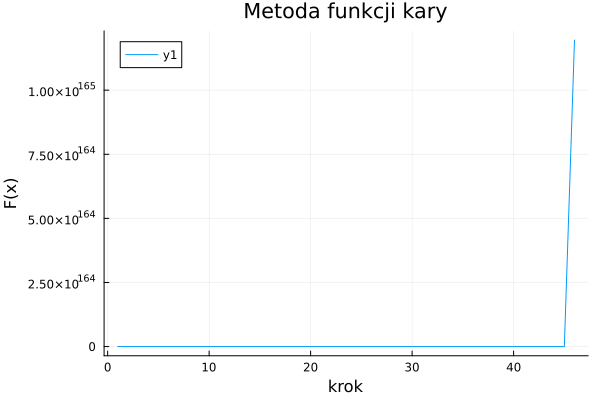

In [164]:
MAXITER = 9

x0 = starting_points[1]  # Można wybrać dowolny punkt startowy

x_opt, history = penalty_gradient_descent(
    f, grad_f!, x0 ; μ0 = 1.0, β = 2.0, max_iter = MAXITER)

plot(history,
     xlabel="krok", ylabel="F(x)", title="Metoda funkcji kary")

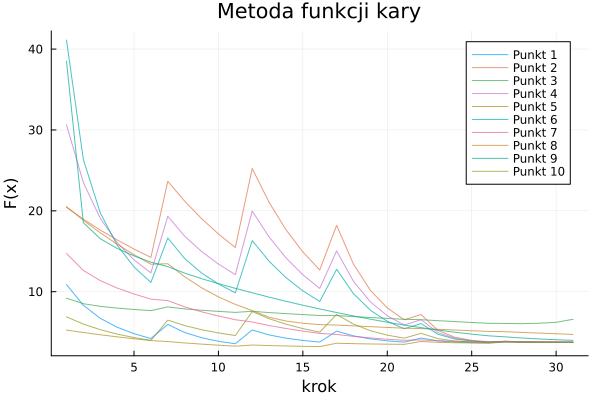

In [165]:
MAXITER = 6

p = plot(xlabel="krok", ylabel="F(x)", title="Metoda funkcji kary")

penalty_histories = [penalty_gradient_descent(f, grad_f!, x0; μ0=1.0, β=2.0, max_iter=MAXITER) |> last
                    for x0 in starting_points]

for (i, hist) in enumerate(penalty_histories)
    plot!(p,  hist, label="Punkt $i", alpha=0.7)
end
display(p)

Roboczo: na początku są wachania potem zbiżają się do zera, potem wybuchają do nieskończoności

Wahania wynikają ze zwiększania parametru μ

TO-DO: zilustrowanie braku zbieżności, szybkiej i powolonej zbieżności -- idk

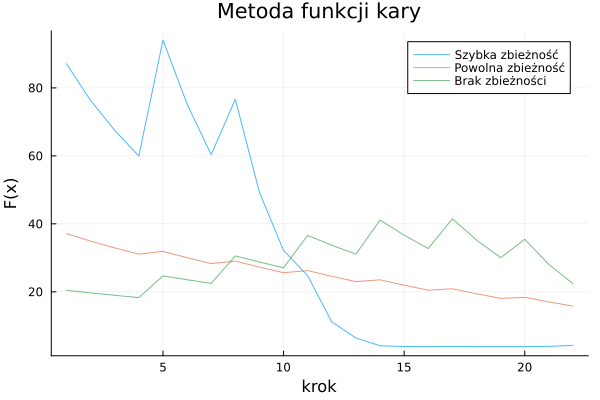

In [166]:
p0 = starting_points[2]

_, h1 = penalty_gradient_descent(f, grad_f!, p0; μ0=5.0, β=2.0, max_iter=7, iter=3, step=0.005)
_, h2 = penalty_gradient_descent(f, grad_f!, p0; μ0=2.0, β=1.1, max_iter=7, iter=3, step=0.005)
_, h3 = penalty_gradient_descent(f, grad_f!, p0; μ0=1.0, β=1.5, max_iter=7, iter=3, step=0.005)
# 5.0, (1.5, 1.1, ), 0.005
# powolna 1.0, 1.01, 0.005
p = plot(xlabel="krok", ylabel="F(x)", title="Metoda funkcji kary")

plot!(p,  h1, label="Szybka zbieżność", alpha=0.7)
plot!(p,  h2, label="Powolna zbieżność", alpha=0.7)
plot!(p,  h3, label="Brak zbieżności", alpha=0.7)

display(p)



Roboczo: Dobrałam takie wskaźniki do powolnej, szybkiej i braku, ale zgaduję, że ,,brak zbieżności" i tak by kiedyś zbiegł (nawet tak było w poleceniu, żeby ,,metoda wykonywała częściową optymalizację dla każdej wielkości paramteru kary"). I tak wszystkie parametry będą prowadziły do wystrzelenia funkcji kary po dużej liczbie iteracji i wynika to z faktu, iż w pewnym miejsu step (niezależnie jak mały), jest zbyt duży by trafić w ,,kanion constraintu". Czat proponuje, by z kroku na krok dzielić step, ale nie ma tego w poleceniu, więc raczej on tego nie oczekuje.

## Na 4.0

In [167]:
# # Optymalizacja metodą z warunkiem Armijo
# function optimize_armijo_step(cost_data, grad_data, x0;
#         step=nothing, maxiter=100, tol=1e-6, c=0.1, rho=0.5)

#     x = copy(x0)
#     g = similar(x)

#     fx = cost_data(x)
#     if !isfinite(fx) 
#         error("cost_data(x0) is not finite (got $fx).")
#     end

#     for k in 1:maxiter
#         grad_data(g, x)
#         any(!isfinite, g) && error("Gradient became non-finite at iter=$k")
#         norm(g) < tol && return x
#         alpha = armijo_line_search(cost_data, x, g; c=c, rho=rho)
#         x .= x .- alpha .* g
#     end
#     return x
# end

# # Zapis historii wyników
# function optimize_armijo_with_history(cost, grad!, x0; maxiter=100, tol=1e-6, 
#             c=0.1, rho=0.5)
#     x = copy(x0)
#     history = Float64[]
#     for k in 1:maxiter
#         push!(history, cost(x))
#         x = optimize_armijo_step(cost, grad!, x; maxiter=1, tol=tol, c=c, rho=rho)
#     end
#     push!(history, cost(x))
#     return x, history
# end

In [188]:
# Optymalizacja metodą z warunkiem Armijo i kierunkiem z CG
# Różnica wględem poprzednego zadania - przekazanie kierunku d do funkcji, zamiast wyniczania -g wewnątrz
function armijo_line_search(cost, x, g, d, x_tmp; c=0.1, rho=0.8) # dodane x_temp

    fx = cost(x)
    slope = dot(g, d)
    alpha = 1.0

    while true
        @. x_tmp = x .+ alpha .* d # dodanie @. i _tmp

        if isfinite(cost(x_tmp)) && cost(x_tmp) <= fx + c * alpha * slope
            break
        end

        alpha *= rho
        alpha < 1e-16 && break
    end

    return alpha
end

function conjugate_gradient(cost, grad!, x0;
        maxiter=100, tol=1e-6, c=0.1, rho=0.8)
    len = length(x0) # dodanie
    x = copy(x0)
    g = zeros(len)
    grad!(g, x)
    x_tmp = zeros(len)
    d = zeros(len)
    @. d = -g # dodanie @.
    g_new = zeros(len) # dodanie

    history = Float64[]

    for k in 1:maxiter

        push!(history, cost(x))
        norm(g) < tol && break

        α = armijo_line_search(cost, x, g, d, x_tmp; c=c, rho=rho)

        @. x = x .+ α .* d # było x_new 

        # g_new = zeros(len) usunięcie
        grad!(g_new, x)

        β = dot(g_new, g_new) / dot(g, g)

        @. d = -g_new .+ β .* d #dodanie @.

        #x = x_new usunięcie
        g .= g_new # dodanie . 
    end

    return x, history
end

conjugate_gradient (generic function with 1 method)

Wprowadzenie metody gradientu sprzężonego z dodatkiem penalty

In [189]:
function penalty_conjugate_gradient(f, grad_f!, x0;
        μ0=1.0, β=2.0, max_iter=10)

    x = copy(x0)
    μ = μ0

    history = Float64[]

    for k in 1:max_iter

        function penalized_f(x)
            return f(x) + μ * g(x)^2
        end

        function penalized_grad!(out, x)

            grad_f!(out, x)
            gx = g(x)
            gg = grad_g(x)
            out .+= 2 * μ * gx .* gg
        end

        tol = 1e-2 / μ

        x, hist = conjugate_gradient( penalized_f, penalized_grad!, x;
            tol = tol, maxiter = 50 )

        append!(history, hist)

        μ *= β
    end

    return x, history
end

penalty_conjugate_gradient (generic function with 1 method)

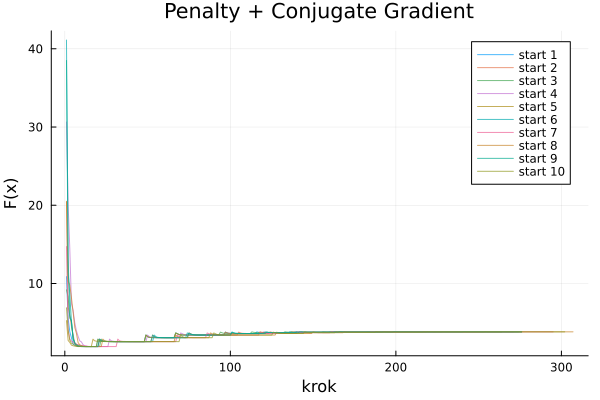

In [190]:
p = plot(xlabel="krok", ylabel="F(x)", title="Penalty + Conjugate Gradient")

histories = [ penalty_conjugate_gradient(f, grad_f!, x0) |> last
    for x0 in starting_points ]

for (i,h) in enumerate(histories)
    plot!(p, h, label="start $i", alpha=0.7)
end


display(p)

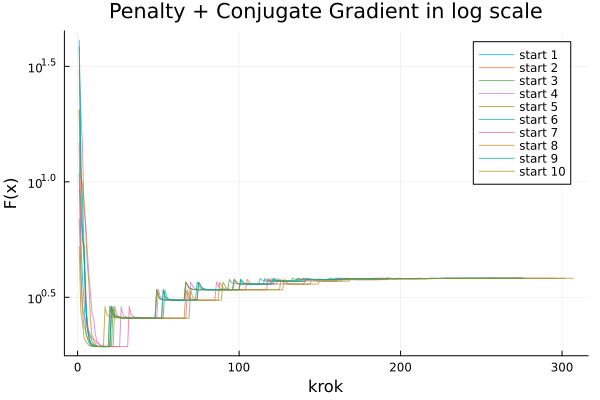

In [191]:
# to samo w log scale dla czytelności zbieżności
p = plot(xlabel="krok", ylabel="F(x)", title="Penalty + Conjugate Gradient in log scale", yscale=:log10)

histories = [ penalty_conjugate_gradient(f, grad_f!, x0) |> last
    for x0 in starting_points ]

for (i,h) in enumerate(histories)
    plot!(p, h, label="start $i", alpha=0.7)
end

display(p)

## Na 5.0

In [176]:
# import Pkg; Pkg.add("BenchmarkTools")
using BenchmarkTools

In [192]:
x_0 = starting_points[1]

println("Benchmark")
benchmark = @btime penalty_conjugate_gradient(f, grad_f!, x0)

Benchmark
  939.400 μs (50185 allocations: 822.15 KiB)


([0.1742354869204875, -2.02657000337154], [10.881389781661747, 5.541287490379835, 3.856824844877778, 3.051713637798879, 2.212638792021187, 2.121520101307973, 2.005884755702831, 1.958318077656175, 1.9496935913415623, 1.9396065349256344  …  3.820985216476619, 3.820985216473721, 3.820985216471383, 3.820985216471194, 3.820985216470991, 3.820985216470593, 3.820985216470237, 3.8209852164694325, 3.8209852164685296, 3.820985216468228])

Bez zmian: 
Benchmark
  1.082 ms (61435 allocations: 1.23 MiB)

Po pierwszych zmianach (dopisane, gdzie co jest):
Benchmark
  939.400 μs (50185 allocations: 822.15 KiB)